# Improved ICP Matching Algorithm Based on Laser Radar and IMU

Trabalho sobre ICP (Iterative Closest Point) aplicado a scans 2D simulados de LiDAR, comparando ICP tradicional com uma versão auxiliada por IMU (giroscópio + acelerômetro do celular).

In [17]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

## 1. ICP 2D com SVD

In [19]:
# alinha dois conjuntos de pontos rotação + translação pra reduzir erro quadrático
def best_fit_transform(A, B):
    centroid_A = np.mean(A, axis=1, keepdims=True)
    centroid_B = np.mean(B, axis=1, keepdims=True)

    AA = A - centroid_A
    BB = B - centroid_B

    H = AA @ BB.T
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    # corrige reflexao (determinante negativo)
    if np.linalg.det(R) < 0:
        Vt[1, :] *= -1
        R = Vt.T @ U.T

    T = centroid_B - R @ centroid_A
    return R, T

In [20]:
# ICP tradicional: repete (achar vizinho mais proximo -> recalcular transformacao) até convergir
def icp_2d(src, dst, init_pose=None, max_iterations=50, tolerance=1e-5):
    if src.shape[1] == 0 or dst.shape[1] == 0:
        raise ValueError(
            f"Erro: Point cloud está vazio (src size: {src.shape[1]}, dst size: {dst.shape[1]}). "
            "Verifique se o robô/celular está no alcance das paredes (10m x 10m)."
        )

    src_copy = np.copy(src)

    R_cum = np.eye(2)
    T_cum = np.zeros((2, 1))

    # aplica chute inicial de pose
    if init_pose is not None:
        R_init, T_init = init_pose
        src_copy = R_init @ src_copy + T_init
        R_cum = R_init
        T_cum = T_init

    # KDTree organiza os pontos da nuvem de destino espacialmente,  realiza buscas de vizinhos mais próximos
    dst_tree = KDTree(dst.T)

    errors = []
    prev_error = float('inf')

    for i in range(max_iterations):
        # laço iterativo do ICP: busca correspondências de menor distância, calcula a rotação e translação ideal (SVD)
        # e aplica o ajuste sobre a nuvem de origem
        distances, indices = dst_tree.query(src_copy.T)
        matched_dst = dst[:, indices]

        mean_error = np.mean(distances ** 2)
        errors.append(mean_error)

        if abs(prev_error - mean_error) < tolerance:
            break
        prev_error = mean_error

        R, T = best_fit_transform(src_copy, matched_dst)
        src_copy = R @ src_copy + T

        R_cum = R @ R_cum
        T_cum = R @ T_cum + T

    return src_copy, R_cum, T_cum, errors

## 2. Pose inicial a partir das retas

In [21]:
# casa retas src/dst pelo ângulo e resolve rotação + translação que alinha elas
def align_lines_2d(lines_src, lines_dst):
    if len(lines_src) < 2 or len(lines_dst) < 2:
        # precisa de pelo menos 2 retas não paralelas pra resolver translação
        return np.eye(2), np.zeros((2, 1))

    matched_pairs = []
    used_dst_indices = set()

    for l_src in lines_src:
        best_idx = -1
        min_angle_diff = float('inf')
        for idx, l_dst in enumerate(lines_dst):
            if idx in used_dst_indices:
                continue
            diff = np.abs(l_src["angle"] - l_dst["angle"])
            diff = np.minimum(diff, np.abs(diff - np.pi))
            diff = np.minimum(diff, np.abs(diff - 2*np.pi))
            if diff < min_angle_diff:
                min_angle_diff = diff
                best_idx = idx
        if best_idx != -1 and min_angle_diff < np.radians(35):
            matched_pairs.append((l_src, lines_dst[best_idx]))
            used_dst_indices.add(best_idx)

    if len(matched_pairs) < 2:
        print("Aviso: Não foi possível corresponder pelo menos 2 retas distintas!")
        return np.eye(2), np.zeros((2, 1))

    # rotação = média das diferencas angulares entre os pares
    rot_angles = []
    for l_src, l_dst in matched_pairs:
        ang_diff = l_dst["angle"] - l_src["angle"]
        ang_diff = (ang_diff + np.pi) % (2 * np.pi) - np.pi
        if np.abs(ang_diff) > np.pi / 2:
            ang_diff = ang_diff - np.sign(ang_diff) * np.pi
        rot_angles.append(ang_diff)

    d_theta = np.mean(rot_angles)

    R = np.array([
        [np.cos(d_theta), -np.sin(d_theta)],
        [np.sin(d_theta), np.cos(d_theta)]
    ])

    # trasnlação resolvendo sistema M*T = b com as duas retas
    M = np.zeros((2, 2))
    b = np.zeros((2, 1))

    for i in range(2):
        l_src, l_dst = matched_pairs[i]
        M[i, :] = l_dst["normal"]
        dot_product = l_dst["normal"] @ (R @ l_src["normal"])
        sign = 1.0 if dot_product > 0 else -1.0
        b[i, 0] = l_dst["rho"] - sign * l_src["rho"]

    if np.abs(np.linalg.det(M)) < 0.1:
        print("Aviso: As retas correspondidas são quase paralelas! A translação não pode ser resolvida com precisão.")
        return R, np.zeros((2, 1))

    T = np.linalg.solve(M, b)
    return R, T

## 3. Leitura dos dados do Sensor Logger (celular)

In [22]:
# lê os csv's de giroscópio/acelerômetro do app Sensor Logger e integra pra achar rotação e translação
def parse_sensor_logger_data(gyro_path, accel_path):
    if not os.path.exists(gyro_path) or not os.path.exists(accel_path):
        print("Aviso: Arquivos do IMU não encontrados. Usando integração de IMU sintético.")
        return None

    gyro_data = np.genfromtxt(gyro_path, delimiter=',', skip_header=1)
    accel_data = np.genfromtxt(accel_path, delimiter=',', skip_header=1)

    # colunas do Sensor Logger: 0 tempo(ns), 1 seg, 2 x, 3 y, 4 z
    t_gyro = gyro_data[:, 0]
    if t_gyro[0] > 1e12:
        t_gyro = (t_gyro - t_gyro[0]) / 1e9
    else:
        t_gyro = t_gyro - t_gyro[0]

    wz = gyro_data[:, 4]  # velocidade angular em z

    # integra wz pra achar o ângulo (yaw)
    theta = 0.0
    thetas = [0.0]
    for idx in range(1, len(t_gyro)):
        dt = t_gyro[idx] - t_gyro[idx-1]
        theta += 0.5 * (wz[idx] + wz[idx-1]) * dt
        thetas.append(theta)

    t_accel = accel_data[:, 0]
    if t_accel[0] > 1e12:
        t_accel = (t_accel - t_accel[0]) / 1e9
    else:
        t_accel = t_accel - t_accel[0]

    ax = accel_data[:, 2]
    ay = accel_data[:, 3]

    # interpola o ângulo nos instantes do acelerômetro
    accel_thetas = np.interp(t_accel, t_gyro, thetas)

    # gira a aceleração local pro referencial global
    ax_world = ax * np.cos(accel_thetas) - ay * np.sin(accel_thetas)
    ay_world = ax * np.sin(accel_thetas) + ay * np.cos(accel_thetas)

    # integra duas vezes (aceleração -> velocidade -> posição)
    vx = 0.0
    vy = 0.0
    px = 0.0
    py = 0.0

    for idx in range(1, len(t_accel)):
        dt = t_accel[idx] - t_accel[idx-1]
        if dt <= 0:
            continue
        vx += 0.5 * (ax_world[idx] + ax_world[idx-1]) * dt
        vy += 0.5 * (ay_world[idx] + ay_world[idx-1]) * dt
        px += vx * dt
        py += vy * dt

    final_theta = thetas[-1]
    R = np.array([
        [np.cos(final_theta), -np.sin(final_theta)],
        [np.sin(final_theta), np.cos(final_theta)]
    ])
    T = np.array([[px], [py]])

    print(f"IMU do celular processado com sucesso:")
    print(f"  Ângulo de rotação (Yaw): {np.degrees(final_theta):.2f}°")
    print(f"  Deslocamento bruto: [{px:.3f}, {py:.3f}]m")

    return R, T

## 4. Simulação do ambiente e do LiDAR

In [23]:
# gera uma sala quadrada 10x10m centrada na origem
def generate_virtual_room(n_points_per_wall=100):
    s = 5.0
    y_vals = np.linspace(-s, s, n_points_per_wall)
    x_vals = np.linspace(-s, s, n_points_per_wall)

    wall_left = np.vstack((np.full_like(y_vals, -s), y_vals))
    wall_top = np.vstack((x_vals, np.full_like(x_vals, s)))
    wall_right = np.vstack((np.full_like(y_vals, s), y_vals))
    wall_bottom = np.vstack((x_vals, np.full_like(x_vals, -s)))

    room_points = np.hstack((wall_left, wall_top, wall_right, wall_bottom))
    return room_points

In [24]:
# simula um scan de LiDAR 2D a partir da posição e orientação do robô
def simulate_lidar_scan(room_points, robot_pos, robot_yaw, max_range=8.0, field_of_view=np.radians(240)):
    R_robot = np.array([
        [np.cos(robot_yaw), -np.sin(robot_yaw)],
        [np.sin(robot_yaw), np.cos(robot_yaw)]
    ])

    # passa os pontos da sala pro referencial local do robô
    local_points = R_robot.T @ (room_points - robot_pos.reshape(2, 1))

    ranges = np.linalg.norm(local_points, axis=0)
    angles = np.arctan2(local_points[1, :], local_points[0, :])

    # filtra por alcance e campo de visão
    fov_mask = (np.abs(angles) <= field_of_view / 2) & (ranges <= max_range)

    scan_points = local_points[:, fov_mask]
    noise = np.random.normal(0, 0.015, size=scan_points.shape)  # ruído de medição (1.5cm)
    scan_points += noise

    return scan_points

## 5. Execução (Caso 1: Bom)

In [25]:
gyro_path = "bom/Gyroscope.csv"
accel_path = "bom/Accelerometer.csv"

# integra e calcula a rotação/translação real a partir dos dados do acelerômetro e giroscópio do celular
if gyro_path and accel_path:
    print(f"Lendo logs do Sensor Logger (BOM): {gyro_path} e {accel_path}...")
    parsed_pose = parse_sensor_logger_data(gyro_path, accel_path)
    if parsed_pose is not None:
        R_imu, T_imu = parsed_pose
        print("\nCálculo do IMU concluído. Executando simulação com os valores processados...")
        np.random.seed(42)
        room = generate_virtual_room()
        dyaw = np.arctan2(R_imu[1,0], R_imu[0,0])
        pos2 = -(R_imu.T @ T_imu).flatten()

        # limita a posicao simulada pra caber na sala 10x10 (o IMU sozinho desvia bastante)
        max_allowed_dist = 2.0
        pos_dist = np.linalg.norm(pos2)
        if pos_dist > max_allowed_dist:
            print(f"\n[Escalonamento de Segurança] A integração real do IMU resultou em um deslocamento massivo de {pos_dist:.3f}m devido ao drift do sensor.")
            print(f"Para manter o robô simulado dentro da sala virtual de 10x10m, o deslocamento foi reduzido para {max_allowed_dist}m.")
            pos2 = (pos2 / pos_dist) * max_allowed_dist
            T_imu = -(R_imu @ pos2.reshape(2, 1))

        scan1 = simulate_lidar_scan(room, np.array([0,0]), 0)
        scan2 = simulate_lidar_scan(room, pos2, -dyaw)

        aligned_std, R_std, T_std, err_std = icp_2d(scan1, scan2, init_pose=None)
        aligned_imu, R_imu_opt, T_imu_opt, err_imu = icp_2d(scan1, scan2, init_pose=(R_imu, T_imu))

        print(f"Iterações do ICP Padrão (Caso 1): {len(err_std)}")
        print(f"Iterações do ICP auxiliado por IMU (Caso 1): {len(err_imu)}")


Lendo logs do Sensor Logger (BOM): bom/Gyroscope.csv e bom/Accelerometer.csv...
IMU do celular processado com sucesso:
  Ângulo de rotação (Yaw): -22.04°
  Deslocamento bruto: [-0.125, 0.703]m

Cálculo do IMU concluído. Executando simulação com os valores processados...
Iterações do ICP Padrão (Caso 1): 29
Iterações do ICP auxiliado por IMU (Caso 1): 11


## 6. Gráficos (Caso 1: Bom)

Gráficos salvos com sucesso como 'icp_matching_results.png'.


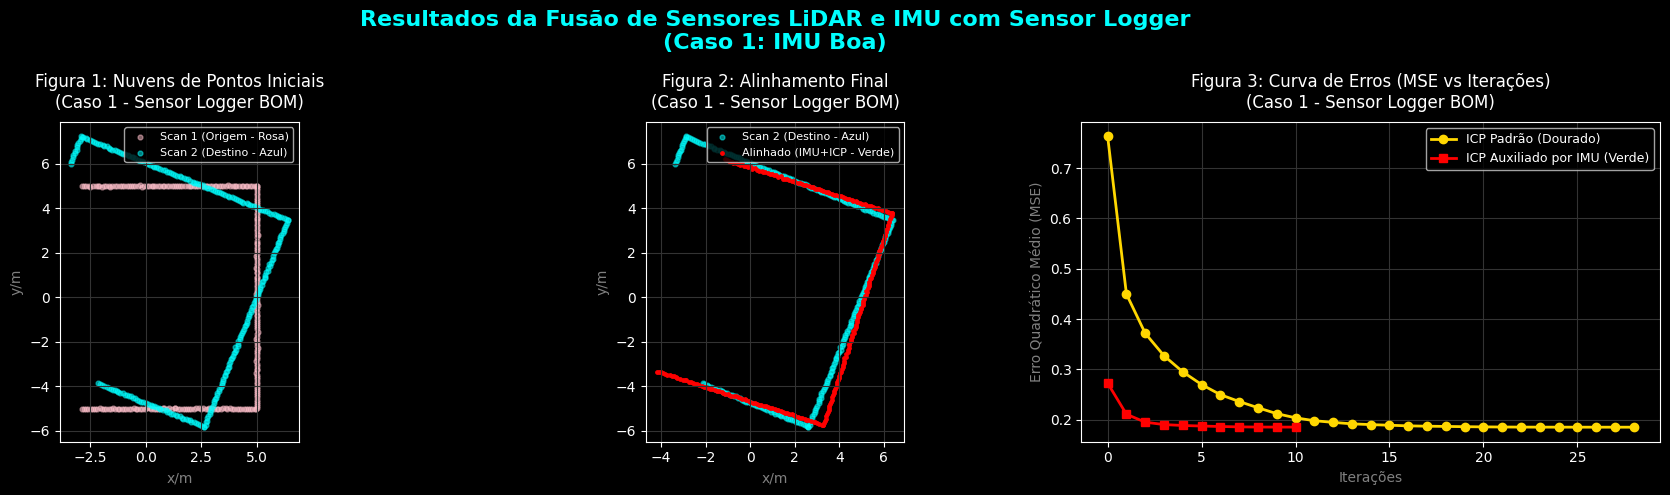

In [26]:
fig = plt.figure(figsize=(18, 5))
fig.suptitle("Resultados da Fusão de Sensores LiDAR e IMU com Sensor Logger\n(Caso 1: IMU Boa)", 
             fontsize=16, color='cyan', fontweight='bold')

c_src = 'pink'
c_dst = 'cyan'
c_std = 'gold'
c_opt = 'red'

ax1 = plt.subplot(1, 3, 1)
ax1.scatter(scan1[0, :], scan1[1, :], s=12, color=c_src, alpha=0.5, label='Scan 1 (Origem - Rosa)')
ax1.scatter(scan2[0, :], scan2[1, :], s=12, color=c_dst, alpha=0.5, label='Scan 2 (Destino - Azul)')
ax1.set_title("Figura 1: Nuvens de Pontos Iniciais\n(Caso 1 - Sensor Logger BOM)", color='white', fontsize=12, pad=10)
ax1.set_xlabel("x/m", color='gray')
ax1.set_ylabel("y/m", color='gray')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, color='#333333')
ax1.set_aspect('equal')

ax2 = plt.subplot(1, 3, 2)
ax2.scatter(scan2[0, :], scan2[1, :], s=12, color=c_dst, alpha=0.5, label='Scan 2 (Destino - Azul)')
ax2.scatter(aligned_imu[0, :], aligned_imu[1, :], s=6, color=c_opt, label='Alinhado (IMU+ICP - Verde)')
ax2.set_title("Figura 2: Alinhamento Final\n(Caso 1 - Sensor Logger BOM)", color='white', fontsize=12, pad=10)
ax2.set_xlabel("x/m", color='gray')
ax2.set_ylabel("y/m", color='gray')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, color='#333333')
ax2.set_aspect('equal')

ax3 = plt.subplot(1, 3, 3)
ax3.plot(err_std, 'o-', color=c_std, linewidth=2, label='ICP Padrão (Dourado)')
ax3.plot(err_imu, 's-', color=c_opt, linewidth=2, label='ICP Auxiliado por IMU (Verde)')
ax3.set_title("Figura 3: Curva de Erros (MSE vs Iterações)\n(Caso 1 - Sensor Logger BOM)", color='white', fontsize=12, pad=10)
ax3.set_xlabel("Iterações", color='gray')
ax3.set_ylabel("Erro Quadrático Médio (MSE)", color='gray')
ax3.legend(fontsize=9)
ax3.grid(True, color='#333333')

plt.tight_layout()
plt.savefig('icp_matching_results.png', dpi=300, bbox_inches='tight')
print("Gráficos salvos com sucesso como 'icp_matching_results.png'.")
plt.show()
plt.style.use('dark_background')

## 7. Execução: Caso 2 (Ruim)

In [29]:
gyro_path = "ruim/Gyroscope.csv"
accel_path = "ruim/Accelerometer.csv"

if gyro_path and accel_path:
    print(f"Lendo logs do Sensor Logger (RUIM): {gyro_path} e {accel_path}...")
    parsed_pose = parse_sensor_logger_data(gyro_path, accel_path)
    if parsed_pose is not None:
        R_imu, T_imu = parsed_pose
        print("\nCálculo do IMU concluído. Executando simulação com os valores processados...")
        np.random.seed(42)
        room = generate_virtual_room()
        dyaw = np.arctan2(R_imu[1,0], R_imu[0,0])
        pos2 = -(R_imu.T @ T_imu).flatten()

        # limita a posicao simulada pra caber na sala 10x10 (o IMU sozinho desvia bastante)
        max_allowed_dist = 2.0
        pos_dist = np.linalg.norm(pos2)
        if pos_dist > max_allowed_dist:
            print(f"\n[Escalonamento de Segurança] A integração real do IMU resultou em um deslocamento massivo de {pos_dist:.3f}m devido ao drift do sensor.")
            print(f"Para manter o robô simulado dentro da sala virtual de 10x10m, o deslocamento foi reduzido para {max_allowed_dist}m.")
            pos2 = (pos2 / pos_dist) * max_allowed_dist
            T_imu = -(R_imu @ pos2.reshape(2, 1))

        scan1 = simulate_lidar_scan(room, np.array([0,0]), 0)
        scan2 = simulate_lidar_scan(room, pos2, -dyaw)

        aligned_std, R_std, T_std, err_std = icp_2d(scan1, scan2, init_pose=None)
        aligned_imu, R_imu_opt, T_imu_opt, err_imu = icp_2d(scan1, scan2, init_pose=(R_imu, T_imu))

        print(f"Iterações do ICP Padrão (Caso 1): {len(err_std)}")
        print(f"Iterações do ICP auxiliado por IMU (Caso 1): {len(err_imu)}")

Lendo logs do Sensor Logger (RUIM): ruim/Gyroscope.csv e ruim/Accelerometer.csv...
IMU do celular processado com sucesso:
  Ângulo de rotação (Yaw): 457.16°
  Deslocamento bruto: [397.685, 232.910]m

Cálculo do IMU concluído. Executando simulação com os valores processados...

[Escalonamento de Segurança] A integração real do IMU resultou em um deslocamento massivo de 460.870m devido ao drift do sensor.
Para manter o robô simulado dentro da sala virtual de 10x10m, o deslocamento foi reduzido para 2.0m.
Iterações do ICP Padrão (Caso 1): 36
Iterações do ICP auxiliado por IMU (Caso 1): 50


## 8. Gráfico (Caso 2: Ruim)

Gráficos salvos com sucesso como 'icp_matching_results.png'.


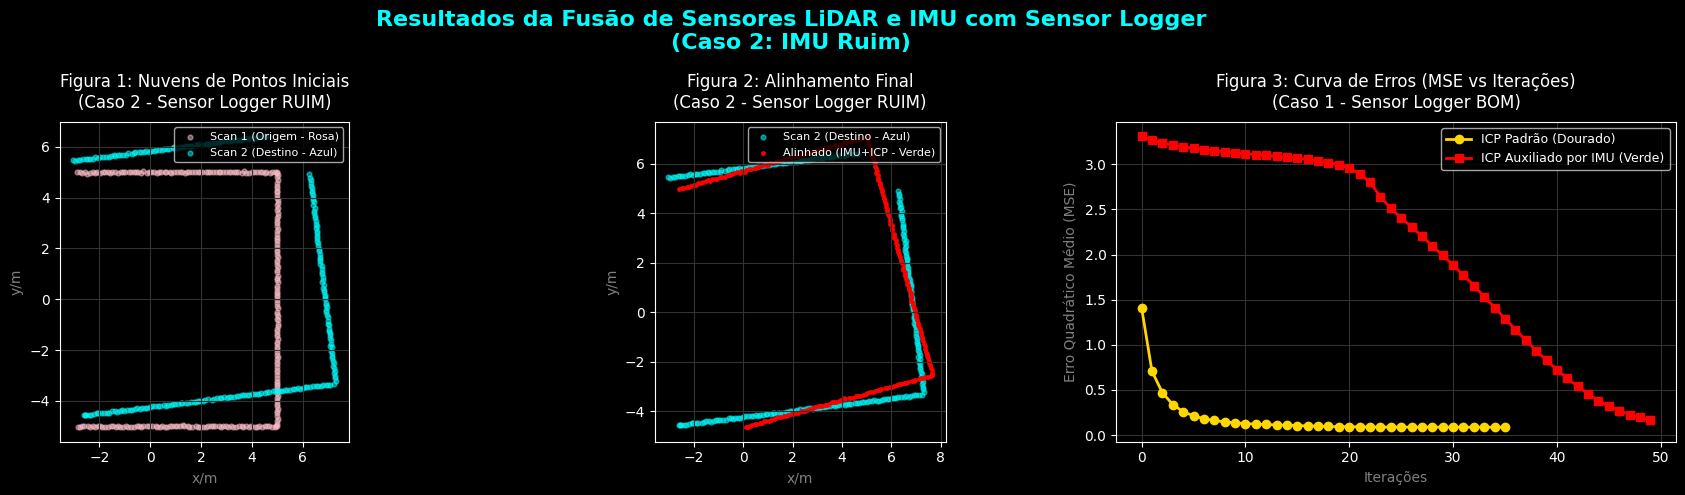

In [30]:
fig = plt.figure(figsize=(18, 5))
fig.suptitle("Resultados da Fusão de Sensores LiDAR e IMU com Sensor Logger\n(Caso 2: IMU Ruim)", 
             fontsize=16, color='cyan', fontweight='bold')

c_src = 'pink'
c_dst = 'cyan'
c_std = 'gold'
c_opt = 'red'

ax1 = plt.subplot(1, 3, 1)
ax1.scatter(scan1[0, :], scan1[1, :], s=12, color=c_src, alpha=0.5, label='Scan 1 (Origem - Rosa)')
ax1.scatter(scan2[0, :], scan2[1, :], s=12, color=c_dst, alpha=0.5, label='Scan 2 (Destino - Azul)')
ax1.set_title("Figura 1: Nuvens de Pontos Iniciais\n(Caso 2 - Sensor Logger RUIM)", color='white', fontsize=12, pad=10)
ax1.set_xlabel("x/m", color='gray')
ax1.set_ylabel("y/m", color='gray')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, color='#333333')
ax1.set_aspect('equal')

ax2 = plt.subplot(1, 3, 2)
ax2.scatter(scan2[0, :], scan2[1, :], s=12, color=c_dst, alpha=0.5, label='Scan 2 (Destino - Azul)')
ax2.scatter(aligned_imu[0, :], aligned_imu[1, :], s=6, color=c_opt, label='Alinhado (IMU+ICP - Verde)')
ax2.set_title("Figura 2: Alinhamento Final\n(Caso 2 - Sensor Logger RUIM)", color='white', fontsize=12, pad=10)
ax2.set_xlabel("x/m", color='gray')
ax2.set_ylabel("y/m", color='gray')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, color='#333333')
ax2.set_aspect('equal')

ax3 = plt.subplot(1, 3, 3)
ax3.plot(err_std, 'o-', color=c_std, linewidth=2, label='ICP Padrão (Dourado)')
ax3.plot(err_imu, 's-', color=c_opt, linewidth=2, label='ICP Auxiliado por IMU (Verde)')
ax3.set_title("Figura 3: Curva de Erros (MSE vs Iterações)\n(Caso 1 - Sensor Logger BOM)", color='white', fontsize=12, pad=10)
ax3.set_xlabel("Iterações", color='gray')
ax3.set_ylabel("Erro Quadrático Médio (MSE)", color='gray')
ax3.legend(fontsize=9)
ax3.grid(True, color='#333333')

plt.tight_layout()
plt.savefig('icp_matching_results.png', dpi=300, bbox_inches='tight')
print("Gráficos salvos com sucesso como 'icp_matching_results.png'.")
plt.show()
plt.style.use('dark_background')